In [1]:
import pandas as pd
import numpy as np

## Dataset Loading

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

## Data Splitting

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("PE", axis=1)
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Scaling

In [6]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

## Tensor Conversion

In [8]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

## Tensor Dataset Creation

In [9]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

## Tensor Data Load

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning : ANN Model

In [11]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            
            # 1st hidden layer :
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer :
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # Output layer :
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

## Loss & Optimizer

In [12]:
import torch.optim as optim 

model = ANN()

# Loss :
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters())

## Training the ANN

In [16]:
train_losses = []
val_losses = []

epochs = 100

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation :

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if (epoch_val_loss < best_val_loss):
        best_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 160972.02509765624 & val loss = 134447.484375
epoch 2/100 ==> train loss = 105190.98854166667 & val loss = 76927.28125
epoch 3/100 ==> train loss = 55897.52786458333 & val loss = 39307.66015625
epoch 4/100 ==> train loss = 30729.89540608724 & val loss = 24379.337890625
epoch 5/100 ==> train loss = 21315.37042236328 & val loss = 18478.67578125
epoch 6/100 ==> train loss = 16821.662358601887 & val loss = 14856.322265625
epoch 7/100 ==> train loss = 13483.371177164714 & val loss = 11694.302734375
epoch 8/100 ==> train loss = 10421.225179036459 & val loss = 8780.171875
epoch 9/100 ==> train loss = 7655.457176717123 & val loss = 6258.16064453125
epoch 10/100 ==> train loss = 5359.446860758463 & val loss = 4285.388671875
epoch 11/100 ==> train loss = 3690.3049560546874 & val loss = 2927.9609375
epoch 12/100 ==> train loss = 2541.2719889322916 & val loss = 2027.113037109375
epoch 13/100 ==> train loss = 1775.0775652567545 & val loss = 1427.9595947265625
epoch 14/1

## Error - Graph :

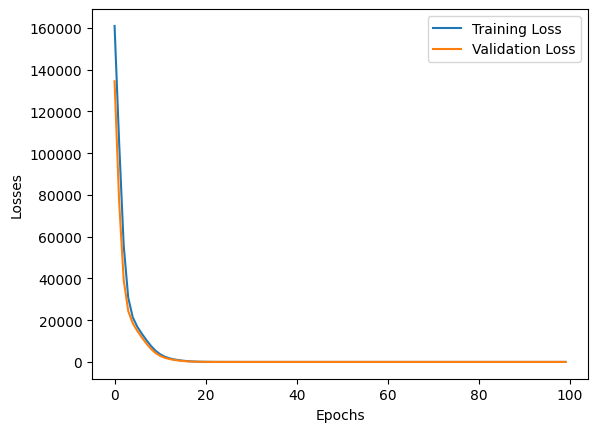

In [18]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

## Load the best Model

In [19]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>